# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Central Tendency

In [2]:
# Sample data
df = pd.DataFrame({
    "values": [8, 10, 19, 10, 10, 20, 12, 15, 15, 18, 15, 20]
})

df

,values
0,8
1,10
2,19
3,10
4,10
5,20
6,12
7,15
8,15
9,18


In [3]:
# Average
mean = df["values"].mean()
print("Mean:", mean)

Mean: 14.333333333333334


In [4]:
# Manual calculation
sum(df["values"])/len(df["values"])

14.333333333333334

In [5]:
# Median
median = df["values"].median()
print("Median:", median)

Median: 15.0


In [6]:
df.quantile(0.5)

,0.5
values,15.0


In [7]:
df.quantile(0.25)

,0.25
values,10.0


In [8]:
sorted_values = sorted(df["values"])
sorted_values

[8, 10, 10, 10, 12, 15, 15, 15, 18, 19, 20, 20]

In [9]:
n = len(sorted_values)

# Manual median calculation
if n % 2 == 1:  # odd length
    median = sorted_values[n // 2]
else:  # even length
    median = (sorted_values[n // 2 - 1] + sorted_values[n // 2]) / 2

median

15.0

In [10]:
# Mode
mode = df["values"].mode()   # mode() returns a Series
mode

,values
0,10
1,15


## Variability

In [11]:
# Three datasets with mean = 10
data1 = [8, 9, 10, 11, 12]        # low variability
data2 = [5, 8, 10, 12, 15]        # medium variability
data3 = [0, 5, 10, 15, 20]        # high variability

datasets = {
    "Low Var": data1,
    "Medium Var": data2,
    "High Var": data3
}
datasets

{'Low Var': [8, 9, 10, 11, 12],
 'Medium Var': [5, 8, 10, 12, 15],
 'High Var': [0, 5, 10, 15, 20]}

In [12]:
results = []

for name, data in datasets.items():
    s = pd.Series(data)
    results.append({
        "Dataset": name,
        "Mean": s.mean(),
        "Variance (pop)": s.var(ddof=0),
        "Std Dev (pop)": s.std(ddof=0),
        "Range": s.max() - s.min()
    })

pd.DataFrame(results)

,Dataset,Mean,Variance (pop),Std Dev (pop),Range
0,Low Var,10.0,2.0,1.414214,4
1,Medium Var,10.0,11.6,3.405877,10
2,High Var,10.0,50.0,7.071068,20


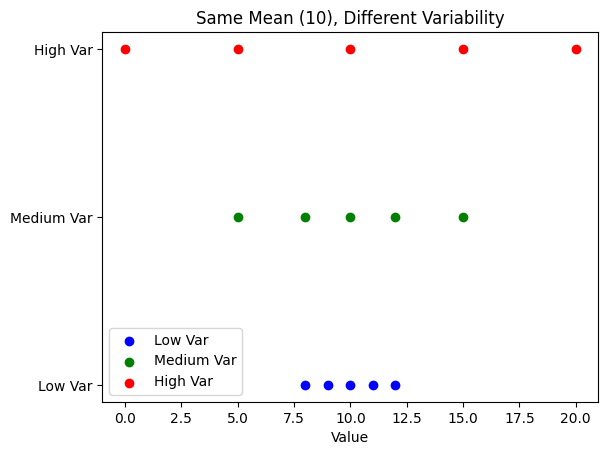

In [13]:
plt.figure()

y_positions = [1, 2, 3]
colors = ["blue", "green", "red"]

for (label, data), y, color in zip(datasets.items(), y_positions, colors):
    plt.scatter(data, [y]*len(data), label=label, color=color)

plt.yticks(y_positions, list(datasets.keys()))
plt.xlabel("Value")
plt.title("Same Mean (10), Different Variability")
plt.legend()

plt.show()

## Distribution

In [14]:
# Few data points
small = np.random.normal(0, 100, 15)
small

array([  76.53736579,  -41.22890813, -213.87936284,   -4.01224196,
         39.72614789, -154.70845995,   32.23656327,  165.82261135,
        213.68951264,   -4.81326824,  227.03824281,   16.10582413,
        101.1109425 , -221.10845284, -126.01659015])

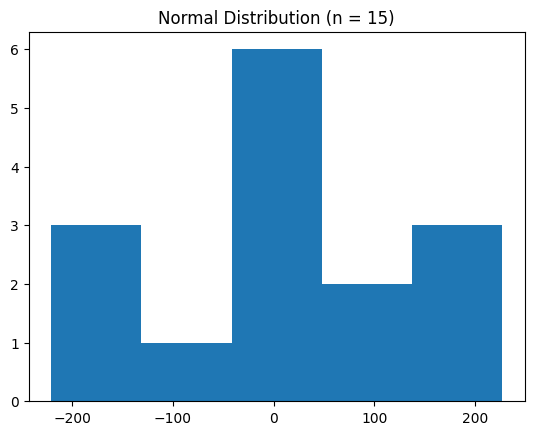

In [15]:
plt.figure()
plt.hist(small, bins=5)
plt.title("Normal Distribution (n = 15)")
plt.show()

In [16]:
# More data points
medium = np.random.normal(0, 100, 100)
medium

array([-100.45510041, -212.02179878, -118.6925877 ,   65.22260819,
        -25.40901587,  100.32477819,   81.86905069,   38.27553452,
        128.66021289,   21.42326814, -107.58078378,  133.92622123,
        -59.47698091, -125.16472068,   30.67903397,  -73.50585303,
        183.96707054,  -13.97120157,   65.51158077,   87.76931143,
        103.69406664,  184.98187476, -255.41053645,  -16.352785  ,
         -2.06823023,  -96.2654845 , -169.69752606,  -54.57026328,
        -67.99187002,  -13.12919798,   17.00807652,   43.20543127,
        143.86662961,    6.28751968,   15.34886354,   32.54870596,
        -73.85322009,  -80.76184404,   51.18110167,  146.11811984,
        156.77329627,   93.89384485,  -76.81502387,   52.17551293,
       -177.5317424 , -151.93547628,   19.01682522,   49.72410415,
         12.97475992,   -9.07260237,  -17.0871029 ,   77.92686075,
        -84.96729949, -134.16712129,  118.12003338, -154.34294538,
        -48.27406988,  -35.86108889,  -48.5558281 ,   75.05347

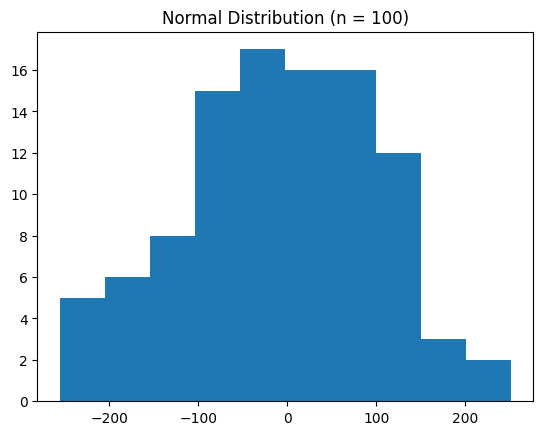

In [17]:
plt.figure()
plt.hist(medium, bins=10)
plt.title("Normal Distribution (n = 100)")
plt.show()

In [18]:
# Lots of data points
large = np.random.normal(0, 100, 5000)
large

array([ -64.03141501,   89.7156934 ,  117.34655427, ..., -166.39522335,
         32.05460329,  -45.119122  ])

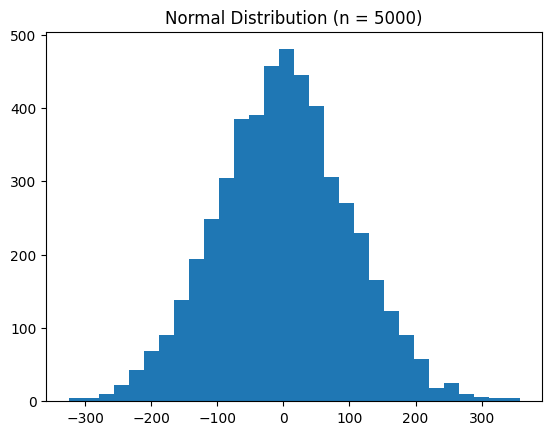

In [19]:
plt.figure()
plt.hist(large, bins=30)
plt.title("Normal Distribution (n = 5000)")
plt.show()

In [20]:
comparison = []

datasets = {
    "Small (n=15)": small,
    "Medium (n=100)": medium,
    "Large (n=5000)": large
}

for name, data in datasets.items():
    s = pd.Series(data)
    comparison.append({
        "Dataset": name,
        "Skewness": s.skew(),
        "Kurtosis": s.kurt()
    })

pd.DataFrame(comparison)

,Dataset,Skewness,Kurtosis
0,Small (n=15),-0.138063,-0.727425
1,Medium (n=100),-0.087877,-0.312477
2,Large (n=5000),0.060273,0.023203
